In [42]:
import time
import os
import copy
import json
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn.functional as F

import torchquantum as tq
import numpy as np

from e2cnn import gspaces
from e2cnn import nn as e2nn

import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import (roc_auc_score, confusion_matrix,
                             classification_report, roc_curve, auc, f1_score)
from sklearn.preprocessing import label_binarize
import seaborn as sns

torch.manual_seed(42)
np.random.seed(42)

os.environ["OMP_NUM_THREADS"] = "1"

print(f"TorchQuantum version: {tq.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

TorchQuantum version: 0.1.8
PyTorch version: 2.5.1+cu124
CUDA available: True


In [43]:
from pathlib import Path
import importlib.util
import subprocess
import sys
import tarfile

CLASS_DIRS = {"axion", "cdm", "no_sub"}

def has_class_folders(root):
    root = Path(root)
    if not root.is_dir():
        return False
    present = {item.name for item in root.iterdir() if item.is_dir()}
    return CLASS_DIRS.issubset(present)

def ensure_gdown():
    if importlib.util.find_spec("gdown") is None:
        print("Installing gdown...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gdown"])
    import gdown
    return gdown

def show_dataset_folder(extract_dir):
    print()
    print("Files in dataset folder:")
    for item in sorted(extract_dir.iterdir()):
        print(item.name)

# Google Drive training dataset file
file_id = "11FVLA4IQgeRXx7Dpem14ayb_JCUD0pxX"
url = f"https://drive.google.com/uc?id={file_id}"

base_dir = Path("/home/jovyan/ssh-test-datavol-1")
extract_dir = base_dir / "dataset"
archive_path = base_dir / "data.tar.gz"
required_roots = [extract_dir / "Model_I"]

base_dir.mkdir(parents=True, exist_ok=True)
extract_dir.mkdir(parents=True, exist_ok=True)

if all(has_class_folders(root) for root in required_roots):
    print("Training dataset already extracted. Skipping gdown install, download, and extraction.")
    for root in required_roots:
        print("Found:", root)
else:
    if archive_path.exists() and archive_path.stat().st_size > 0:
        print("Using existing downloaded archive:", archive_path)
    else:
        if archive_path.exists():
            archive_path.unlink()
            print("Deleted empty/partial archive:", archive_path)
        print("Downloading training dataset...")
        gdown = ensure_gdown()
        gdown.download(url, str(archive_path), quiet=False)

    print("Archive path:", archive_path)
    print("File size GB:", round(archive_path.stat().st_size / 1024**3, 3))
    print("Extracting into:", extract_dir)
    with tarfile.open(archive_path, "r:gz") as tar:
        tar.extractall(extract_dir)

    print("Extracted to:", extract_dir)
    archive_path.unlink()
    print("Deleted downloaded archive:", archive_path)

    missing = [root for root in required_roots if not has_class_folders(root)]
    if missing:
        raise FileNotFoundError(f"Expected class folders not found after extraction: {missing}")

show_dataset_folder(extract_dir)


Training dataset already extracted. Skipping gdown install, download, and extraction.
Found: /home/jovyan/ssh-test-datavol-1/dataset/Model_I

Files in dataset folder:
Model_I
Model_I_test


In [44]:
from pathlib import Path
import importlib.util
import subprocess
import sys
import tarfile

CLASS_DIRS = {"axion", "cdm", "no_sub"}

def has_class_folders(root):
    root = Path(root)
    if not root.is_dir():
        return False
    present = {item.name for item in root.iterdir() if item.is_dir()}
    return CLASS_DIRS.issubset(present)

def ensure_gdown():
    if importlib.util.find_spec("gdown") is None:
        print("Installing gdown...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gdown"])
    import gdown
    return gdown

def show_dataset_folder(extract_dir):
    print()
    print("Files in dataset folder:")
    for item in sorted(extract_dir.iterdir()):
        print(item.name)

# Google Drive test dataset file
file_id = "1Y_q5ene_s0SML3TjRw6sjh8E_SQJD8zU"
url = f"https://drive.google.com/uc?id={file_id}"

base_dir = Path("/home/jovyan/ssh-test-datavol-1")
extract_dir = base_dir / "dataset"
archive_path = base_dir / "testdata.tar.gz"
required_roots = [extract_dir / "Model_I_test"]

base_dir.mkdir(parents=True, exist_ok=True)
extract_dir.mkdir(parents=True, exist_ok=True)

if all(has_class_folders(root) for root in required_roots):
    print("Test dataset already extracted. Skipping gdown install, download, and extraction.")
    for root in required_roots:
        print("Found:", root)
else:
    if archive_path.exists() and archive_path.stat().st_size > 0:
        print("Using existing downloaded archive:", archive_path)
    else:
        if archive_path.exists():
            archive_path.unlink()
            print("Deleted empty/partial archive:", archive_path)
        print("Downloading test dataset...")
        gdown = ensure_gdown()
        gdown.download(url, str(archive_path), quiet=False)

    print("Archive path:", archive_path)
    print("File size GB:", round(archive_path.stat().st_size / 1024**3, 3))
    print("Extracting into:", extract_dir)
    print("This may take time...")
    with tarfile.open(archive_path, "r:gz") as tar:
        tar.extractall(extract_dir)

    print("Extracted to:", extract_dir)
    archive_path.unlink()
    print("Deleted downloaded archive:", archive_path)

    missing = [root for root in required_roots if not has_class_folders(root)]
    if missing:
        raise FileNotFoundError(f"Expected class folders not found after extraction: {missing}")

show_dataset_folder(extract_dir)


Test dataset already extracted. Skipping gdown install, download, and extraction.
Found: /home/jovyan/ssh-test-datavol-1/dataset/Model_I_test

Files in dataset folder:
Model_I
Model_I_test


In [45]:
# Quantum: 8-qubit p4m Equivariant QCNN (33 trainable quantum params)
n_qubits = 8

# Training
step = 0.001
batch_size = 64
weight_decay = 1e-5
num_epochs = 50
patience = 12
WARMUP_EPOCHS = 5

# Model
img_size = 150
in_channels = 1
num_classes = 3
DROPOUT_RATE = 0.3

# Performance knobs. Set DEEPLENSE_CACHE_DATA=0 if RAM is tight.
CACHE_DATA_IN_MEMORY = os.environ.get("DEEPLENSE_CACHE_DATA", "1") != "0"
NUM_WORKERS = int(os.environ.get("DEEPLENSE_NUM_WORKERS", str(min(4, os.cpu_count() or 0))))
PREFETCH_FACTOR = int(os.environ.get("DEEPLENSE_PREFETCH_FACTOR", "4"))
PIN_MEMORY = torch.cuda.is_available()

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass

# Data paths - UPDATE THESE
NOTEBOOK_NAME = "equiqnn"
# Change this string to model_1/model_2/model_3/model_4 when changing data paths.
DATASET_ID = "model_1"
DATASET_ID = os.environ.get("DEEPLENSE_DATASET_ID", DATASET_ID)

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for path in (start, *start.parents):
        if (path / "README.md").exists() and (path / "notebooks").exists():
            return path
    return start

def slugify(value):
    value = str(value).strip().lower()
    slug = "".join(ch if ch.isalnum() else "_" for ch in value)
    slug = "_".join(part for part in slug.split("_") if part)
    return slug or "model_1"

DATASET_ID = slugify(DATASET_ID)
VALID_DATASET_IDS = {f"model_{i}" for i in range(1, 5)}
if DATASET_ID not in VALID_DATASET_IDS:
    raise ValueError(f"DATASET_ID must be one of {sorted(VALID_DATASET_IDS)}, got {DATASET_ID!r}")

DATASET_ROOTS = {
    "model_1": "/home/jovyan/ssh-test-datavol-1/dataset/Model_I",
    "model_2": "/home/jovyan/ssh-test-datavol-1/dataset/Model_II",
    "model_3": "/home/jovyan/ssh-test-datavol-1/dataset/Model_III",
    "model_4": "/home/jovyan/ssh-test-datavol-1/dataset/Model_IV",
}
TEST_ROOTS = {
    "model_1": "/home/jovyan/ssh-test-datavol-1/dataset/Model_I_test",
    "model_2": "/home/jovyan/ssh-test-datavol-1/dataset/Model_II_test",
    "model_3": "/home/jovyan/ssh-test-datavol-1/dataset/Model_III_test",
    "model_4": "/home/jovyan/ssh-test-datavol-1/dataset/Model_IV_test",
}
DATA_ROOT = os.environ.get("DEEPLENSE_DATA_ROOT", DATASET_ROOTS[DATASET_ID])
TEST_DIR = os.environ.get("DEEPLENSE_TEST_DIR", TEST_ROOTS[DATASET_ID])
VAL_SPLIT = float(os.environ.get("DEEPLENSE_VAL_SPLIT", "0.20"))
if not 0.0 < VAL_SPLIT < 1.0:
    raise ValueError(f"VAL_SPLIT must be between 0 and 1, got {VAL_SPLIT}")

PROJECT_ROOT = find_project_root()
CLASSIFICATION_RUN_DIR = PROJECT_ROOT / "notebooks" / "equivariant" / NOTEBOOK_NAME / DATASET_ID
RESULTS_DIR = CLASSIFICATION_RUN_DIR / "results"
CHECKPOINT_DIR = CLASSIFICATION_RUN_DIR / "checkpoints"
CHECKPOINT_PATH = CHECKPOINT_DIR / f"best_{NOTEBOOK_NAME}_{DATASET_ID}.pth"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RUN_METADATA_PATH = CLASSIFICATION_RUN_DIR / "run_metadata.json"
with RUN_METADATA_PATH.open("w") as f:
    json.dump({
        "notebook_name": NOTEBOOK_NAME,
        "dataset_id": DATASET_ID,
        "data_root": str(DATA_ROOT),
        "test_dir": str(TEST_DIR),
        "val_split": VAL_SPLIT,
        "run_dir": str(CLASSIFICATION_RUN_DIR),
        "results_dir": str(RESULTS_DIR),
        "checkpoint_path": str(CHECKPOINT_PATH),
    }, f, indent=2)

print(f"DATA_ROOT: {DATA_ROOT}")
print(f"TEST_DIR:  {TEST_DIR}")
print(f"VAL_SPLIT: {VAL_SPLIT:.2f}")
print(f"Dataset/run id: {DATASET_ID}")
print(f"Run directory: {CLASSIFICATION_RUN_DIR}")
print(f"Results directory: {RESULTS_DIR}")
print(f"Checkpoint path: {CHECKPOINT_PATH}")
print(f"Run metadata: {RUN_METADATA_PATH}")

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Architecture: p4m Equivariant QCNN")
print(f"Quantum: {n_qubits} qubits, 33 trainable params (3 conv × 6 + 3 pool × 5)")
print(f"Image size: {img_size}x{img_size}, Classes: {num_classes}")
print(f"Device: {device}")
print(f"Cache in RAM default: {CACHE_DATA_IN_MEMORY}")
print(f"DataLoader workers: {NUM_WORKERS}, prefetch_factor={PREFETCH_FACTOR}, pin_memory={PIN_MEMORY}")


DATA_ROOT: /home/jovyan/ssh-test-datavol-1/dataset/Model_I
TEST_DIR:  /home/jovyan/ssh-test-datavol-1/dataset/Model_I_test
VAL_SPLIT: 0.20
Dataset/run id: model_1
Run directory: /home/jovyan/ssh-test-datavol-1/deeplense-quantum/notebooks/equivariant/equiqnn/model_1
Results directory: /home/jovyan/ssh-test-datavol-1/deeplense-quantum/notebooks/equivariant/equiqnn/model_1/results
Checkpoint path: /home/jovyan/ssh-test-datavol-1/deeplense-quantum/notebooks/equivariant/equiqnn/model_1/checkpoints/best_equiqnn_model_1.pth
Run metadata: /home/jovyan/ssh-test-datavol-1/deeplense-quantum/notebooks/equivariant/equiqnn/model_1/run_metadata.json
Architecture: p4m Equivariant QCNN
Quantum: 8 qubits, 33 trainable params (3 conv × 6 + 3 pool × 5)
Image size: 150x150, Classes: 3
Device: cuda:0
Cache in RAM default: True
DataLoader workers: 4, prefetch_factor=4, pin_memory=True


In [46]:
IMAGE_KEYS = ("image", "img", "x", "data", "array", "arr", "lens", "sample")

def extract_image_array(value):
    """Return the image array from raw .npy content, including object arrays."""
    if isinstance(value, np.ndarray):
        if value.dtype == object:
            if value.ndim == 0:
                return extract_image_array(value.item())
            for item in value.reshape(-1):
                try:
                    candidate = extract_image_array(item)
                    if np.asarray(candidate).ndim >= 2:
                        return candidate
                except Exception:
                    continue
            return np.asarray(value.tolist())
        return value

    if isinstance(value, dict):
        for key in IMAGE_KEYS:
            if key in value:
                return extract_image_array(value[key])
        for item in value.values():
            try:
                candidate = extract_image_array(item)
                if np.asarray(candidate).ndim >= 2:
                    return candidate
            except Exception:
                continue
        raise ValueError("Could not find an image-like array in .npy dict")

    if isinstance(value, (list, tuple)):
        for item in value:
            try:
                candidate = extract_image_array(item)
                if np.asarray(candidate).ndim >= 2:
                    return candidate
            except Exception:
                continue
        return np.asarray(value)

    return np.asarray(value)

def load_npy_image(filepath):
    raw = np.load(filepath, allow_pickle=True)
    arr = np.asarray(extract_image_array(raw))
    if arr.dtype == object:
        arr = np.asarray(extract_image_array(arr), dtype=np.float32)
    else:
        arr = arr.astype(np.float32, copy=False)

    arr = np.squeeze(arr)
    if arr.ndim == 2:
        arr = arr[np.newaxis, :, :]
    elif arr.ndim == 3:
        if arr.shape[0] not in (1, 3):
            arr = arr.transpose(2, 0, 1)
    else:
        raise ValueError(f"Expected a 2D or 3D image array from {filepath}, got shape {arr.shape}")

    if arr.size == 0:
        raise ValueError(f"Empty image array in {filepath}")

    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    arr_max = float(np.max(arr))
    if arr_max > 1.0:
        arr = arr / arr_max
    return arr.astype(np.float32, copy=False)


class NPYImageFolder(Dataset):
    """Dataset loader for .npy image files organized in class folders."""

    def __init__(self, root_dir, transform=None, samples=None, classes=None, class_to_idx=None, cache=False):
        self.root_dir = str(root_dir)
        self.transform = transform
        self.cache = None
        if not os.path.isdir(self.root_dir):
            raise FileNotFoundError(
                f"Dataset directory not found: {self.root_dir}\n"
                "Expected class folders like axion/, cdm/, no_sub/."
            )

        self.classes = list(classes) if classes is not None else sorted(
            d for d in os.listdir(self.root_dir)
            if os.path.isdir(os.path.join(self.root_dir, d))
        )
        self.class_to_idx = dict(class_to_idx) if class_to_idx is not None else {
            cls: idx for idx, cls in enumerate(self.classes)
        }

        if samples is None:
            self.samples = []
            for class_name in self.classes:
                class_dir = os.path.join(self.root_dir, class_name)
                for filename in sorted(os.listdir(class_dir)):
                    if filename.endswith(".npy"):
                        filepath = os.path.join(class_dir, filename)
                        self.samples.append((filepath, self.class_to_idx[class_name]))
        else:
            self.samples = list(samples)

        if not self.samples:
            raise RuntimeError(f"No .npy files found under {self.root_dir}")

        print(f"Found {len(self.samples)} samples in {self.root_dir}")
        print(f"Classes: {self.classes}")

        if cache:
            desc = f"cache {Path(self.root_dir).name}"
            print(f"Caching {len(self.samples)} decoded samples from {self.root_dir} in RAM...")
            self.cache = [
                torch.from_numpy(np.ascontiguousarray(load_npy_image(filepath))).float()
                for filepath, _ in tqdm(self.samples, desc=desc, leave=False)
            ]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        filepath, label = self.samples[idx]
        if self.cache is None:
            arr = load_npy_image(filepath)
            tensor = torch.from_numpy(np.ascontiguousarray(arr)).float()
        else:
            tensor = self.cache[idx]

        if self.transform:
            tensor = self.transform(tensor)

        return tensor, label


class NPYTransform:
    """Transform for NPY images with optional augmentation."""

    def __init__(self, img_size, augment=False):
        self.img_size = img_size
        self.augment = augment

    def __call__(self, x):
        if x.shape[-1] != self.img_size or x.shape[-2] != self.img_size:
            x = F.interpolate(x.unsqueeze(0), size=(self.img_size, self.img_size),
                              mode="bilinear", align_corners=False).squeeze(0)

        if self.augment:
            if torch.rand(1) > 0.5:
                k = torch.randint(0, 4, (1,)).item()
                if k > 0:
                    x = torch.rot90(x, k, dims=[-2, -1])
            if torch.rand(1) > 0.5:
                x = torch.flip(x, dims=[-1])
            if torch.rand(1) > 0.5:
                x = torch.flip(x, dims=[-2])
            if torch.rand(1) > 0.7:
                noise_std = torch.rand(1).item() * 0.03
                noise = torch.randn_like(x) * noise_std
                x = torch.clamp(x + noise, 0, 1)
            if torch.rand(1) > 0.7:
                bf = 0.8 + torch.rand(1).item() * 0.4
                x = torch.clamp(x * bf, 0, 1)

        return x


def stratified_train_val_samples(samples, val_split=0.20, seed=42):
    """Split a single class-folder dataset into train/val while preserving each class."""
    labels = np.array([label for _, label in samples])
    rng = np.random.default_rng(seed)
    train_indices, val_indices = [], []

    for class_id in sorted(np.unique(labels).tolist()):
        class_indices = np.where(labels == class_id)[0]
        rng.shuffle(class_indices)
        if len(class_indices) <= 1:
            n_val = 0
        else:
            n_val = max(1, int(round(len(class_indices) * val_split)))
            n_val = min(n_val, len(class_indices) - 1)
        val_indices.extend(class_indices[:n_val].tolist())
        train_indices.extend(class_indices[n_val:].tolist())

    rng.shuffle(train_indices)
    rng.shuffle(val_indices)
    train_samples = [samples[i] for i in train_indices]
    val_samples = [samples[i] for i in val_indices]
    if not train_samples or not val_samples:
        raise ValueError("Train/val split is empty. Check VAL_SPLIT and per-class sample counts.")
    return train_samples, val_samples


def make_dataloader(dataset, batch_size, shuffle):
    kwargs = {
        "batch_size": batch_size,
        "shuffle": shuffle,
        "num_workers": NUM_WORKERS,
        "pin_memory": PIN_MEMORY,
    }
    if NUM_WORKERS > 0:
        kwargs["persistent_workers"] = True
        kwargs["prefetch_factor"] = PREFETCH_FACTOR
    return DataLoader(dataset, **kwargs)


def get_dataloaders(data_root, test_dir, img_size, batch_size, val_split=0.20, seed=42):
    """Create train/validation from DATA_ROOT and test from TEST_DIR."""
    train_transform = NPYTransform(img_size, augment=True)
    val_transform = NPYTransform(img_size, augment=False)

    full_dataset = NPYImageFolder(data_root, transform=None, cache=False)
    train_samples, val_samples = stratified_train_val_samples(
        full_dataset.samples, val_split=val_split, seed=seed
    )
    train_dataset = NPYImageFolder(
        data_root, train_transform, samples=train_samples,
        classes=full_dataset.classes, class_to_idx=full_dataset.class_to_idx,
        cache=CACHE_DATA_IN_MEMORY,
    )
    val_dataset = NPYImageFolder(
        data_root, val_transform, samples=val_samples,
        classes=full_dataset.classes, class_to_idx=full_dataset.class_to_idx,
        cache=CACHE_DATA_IN_MEMORY,
    )
    test_dataset = NPYImageFolder(test_dir, val_transform, cache=CACHE_DATA_IN_MEMORY)

    if test_dataset.classes != full_dataset.classes:
        raise ValueError(
            f"Class folders differ between DATA_ROOT and TEST_DIR: "
            f"{full_dataset.classes} vs {test_dataset.classes}"
        )

    train_loader = make_dataloader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = make_dataloader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = make_dataloader(test_dataset, batch_size=batch_size, shuffle=False)

    print(f"Split from DATA_ROOT: train={len(train_dataset)} val={len(val_dataset)}")
    print(f"Separate TEST_DIR: test={len(test_dataset)}")
    print(f"Cache in RAM: {'ON' if CACHE_DATA_IN_MEMORY else 'OFF'}")
    print(f"DataLoader workers: {NUM_WORKERS}, pin_memory={PIN_MEMORY}")
    return train_loader, val_loader, test_loader, full_dataset.classes


In [47]:
class EquivariantQCNN(tq.QuantumModule):
    """
    p4m Equivariant Quantum Convolutional Neural Network (TorchQuantum).


    Uses equivariant U2 gates (RX + IsingZZ + RX + IsingYY) and
    equivariant pooling (RX + RY + RZ + CRX).

    Structure:
        Conv1 (8 qubit pairs) → Pool1 (8→4) →
        Conv2 (4 qubit pairs) → Pool2 (4→2) →
        Conv3 (2 qubit pair)  → Pool3 (2→1) → H(4)

    Trainable quantum parameters: 33 (3×6 conv + 3×5 pool)
    """

    def __init__(self, n_qubits=8):
        super().__init__()
        self.n_qubits = n_qubits

        self.conv1_params = nn.Parameter(0.1 * torch.randn(6))
        self.conv2_params = nn.Parameter(0.1 * torch.randn(6))
        self.conv3_params = nn.Parameter(0.1 * torch.randn(6))

        self.pool1_params = nn.Parameter(0.1 * torch.randn(5))
        self.pool2_params = nn.Parameter(0.1 * torch.randn(5))
        self.pool3_params = nn.Parameter(0.1 * torch.randn(5))

        self.measure = tq.MeasureAll(tq.PauliZ)

    def _expand(self, params, bsz):
        return params.unsqueeze(0).expand(bsz, -1)

    def _ising_zz(self, qdev, theta, w0, w1):
        """IsingZZ(θ) = exp(-iθ/2 Z⊗Z) via CNOT-RZ-CNOT."""
        qdev.cnot(wires=[w0, w1])
        qdev.rz(wires=w1, params=theta)
        qdev.cnot(wires=[w0, w1])

    def _ising_yy(self, qdev, theta, w0, w1, pi2):
        """IsingYY(θ) = exp(-iθ/2 Y⊗Y) via RX(±π/2) basis change + ZZ."""
        qdev.rx(wires=w0, params=pi2)
        qdev.rx(wires=w1, params=pi2)
        qdev.cnot(wires=[w0, w1])
        qdev.rz(wires=w1, params=theta)
        qdev.cnot(wires=[w0, w1])
        qdev.rx(wires=w0, params=-pi2)
        qdev.rx(wires=w1, params=-pi2)

    def _u2_equiv(self, qdev, p, w0, w1, pi2):
        """Equivariant U2 gate: RX-RX-IsingZZ-RX-RX-IsingYY (6 params)."""
        qdev.rx(wires=w0, params=p[:, 0])
        qdev.rx(wires=w1, params=p[:, 1])
        self._ising_zz(qdev, p[:, 2], w0, w1)
        qdev.rx(wires=w0, params=p[:, 3])
        qdev.rx(wires=w1, params=p[:, 4])
        self._ising_yy(qdev, p[:, 5], w0, w1, pi2)

    def _crx_decomposed(self, qdev, theta, ctrl, tgt):
        """CRX(θ) decomposed as H-RZ(θ/2)-CNOT-RZ(-θ/2)-CNOT-H."""
        qdev.h(wires=tgt)
        qdev.rz(wires=tgt, params=theta / 2)
        qdev.cnot(wires=[ctrl, tgt])
        qdev.rz(wires=tgt, params=-theta / 2)
        qdev.cnot(wires=[ctrl, tgt])
        qdev.h(wires=tgt)

    def _pool_equiv(self, qdev, p, w0, w1):
        """Equivariant pooling: RX-RX-RY-RZ-CRX (5 params). Pools w0 → w1."""
        qdev.rx(wires=w1, params=p[:, 0])
        qdev.rx(wires=w0, params=p[:, 1])
        qdev.ry(wires=w0, params=p[:, 2])
        qdev.rz(wires=w0, params=p[:, 3])
        self._crx_decomposed(qdev, p[:, 4], w0, w1)

    def forward(self, q_in):
        bsz = q_in.shape[0]
        dev = q_in.device

        qdev = tq.QuantumDevice(n_wires=self.n_qubits, bsz=bsz, device=dev)
        pi2 = torch.full((bsz,), np.pi / 2, device=dev, dtype=q_in.dtype)

        c1 = self._expand(self.conv1_params, bsz)
        p1 = self._expand(self.pool1_params, bsz)
        c2 = self._expand(self.conv2_params, bsz)
        p2 = self._expand(self.pool2_params, bsz)
        c3 = self._expand(self.conv3_params, bsz)
        p3 = self._expand(self.pool3_params, bsz)

        # Angle encoding via RY
        for i in range(self.n_qubits):
            qdev.ry(wires=i, params=q_in[:, i])

        # Conv1: U2_equiv on adjacent pairs + cross pairs (weight-shared)
        for i in range(4):
            self._u2_equiv(qdev, c1, 2 * i, 2 * i + 1, pi2)
        self._u2_equiv(qdev, c1, 1, 2, pi2)
        self._u2_equiv(qdev, c1, 5, 6, pi2)
        self._u2_equiv(qdev, c1, 0, 3, pi2)
        self._u2_equiv(qdev, c1, 4, 7, pi2)

        # Pool1: 8 → 4 active qubits (odd → even)
        for i in range(4):
            self._pool_equiv(qdev, p1, 2 * i + 1, 2 * i)

        # Conv2: U2_equiv on remaining pairs (0,2) and (4,6)
        self._u2_equiv(qdev, c2, 0, 2, pi2)
        self._u2_equiv(qdev, c2, 4, 6, pi2)

        # Pool2: 4 → 2 active qubits
        self._pool_equiv(qdev, p2, 2, 0)
        self._pool_equiv(qdev, p2, 6, 4)

        # Conv3: U2_equiv on final pair (0, 4)
        self._u2_equiv(qdev, c3, 0, 4, pi2)

        # Pool3: 2 → 1 active qubit
        self._pool_equiv(qdev, p3, 0, 4)

        # Hadamard on output qubit
        qdev.h(wires=4)

        return self.measure(qdev)


In [48]:
from e2cnn import gspaces
from e2cnn import nn as e2nn


class C8SteerableCNN_Features(nn.Module):
    """C8 Steerable CNN for rotation-equivariant feature extraction."""

    def __init__(self, n_rotations=4):
        super().__init__()

        self.r2_act = gspaces.Rot2dOnR2(N=n_rotations)

        in_type = e2nn.FieldType(self.r2_act, [self.r2_act.trivial_repr])
        self.input_type = in_type

        out_type = e2nn.FieldType(self.r2_act, 24 * [self.r2_act.regular_repr])
        self.block1 = e2nn.SequentialModule(
            e2nn.MaskModule(in_type, 150, margin=1),
            e2nn.R2Conv(in_type, out_type, kernel_size=7, padding=1, bias=False),
            e2nn.InnerBatchNorm(out_type),
            e2nn.ReLU(out_type, inplace=True)
        )

        in_type = self.block1.out_type
        out_type = e2nn.FieldType(self.r2_act, 48 * [self.r2_act.regular_repr])
        self.block2 = e2nn.SequentialModule(
            e2nn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            e2nn.InnerBatchNorm(out_type),
            e2nn.ReLU(out_type, inplace=True)
        )
        self.pool1 = e2nn.PointwiseAvgPoolAntialiased(out_type, sigma=0.66, stride=2)

        in_type = self.block2.out_type
        out_type = e2nn.FieldType(self.r2_act, 48 * [self.r2_act.regular_repr])
        self.block3 = e2nn.SequentialModule(
            e2nn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            e2nn.InnerBatchNorm(out_type),
            e2nn.ReLU(out_type, inplace=True)
        )

        in_type = self.block3.out_type
        out_type = e2nn.FieldType(self.r2_act, 96 * [self.r2_act.regular_repr])
        self.block4 = e2nn.SequentialModule(
            e2nn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            e2nn.InnerBatchNorm(out_type),
            e2nn.ReLU(out_type, inplace=True)
        )
        self.pool2 = e2nn.PointwiseAvgPoolAntialiased(out_type, sigma=0.66, stride=2)

        in_type = self.block4.out_type
        out_type = e2nn.FieldType(self.r2_act, 96 * [self.r2_act.regular_repr])
        self.block5 = e2nn.SequentialModule(
            e2nn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            e2nn.InnerBatchNorm(out_type),
            e2nn.ReLU(out_type, inplace=True)
        )

        in_type = self.block5.out_type
        out_type = e2nn.FieldType(self.r2_act, 64 * [self.r2_act.regular_repr])
        self.block6 = e2nn.SequentialModule(
            e2nn.R2Conv(in_type, out_type, kernel_size=5, padding=1, bias=False),
            e2nn.InnerBatchNorm(out_type),
            e2nn.ReLU(out_type, inplace=True)
        )
        self.pool3 = e2nn.PointwiseAvgPoolAntialiased(out_type, sigma=0.66, stride=1, padding=0)

        self.gpool = e2nn.GroupPooling(out_type)
        self.feature_size = self.gpool.out_type.size

    def forward(self, x):
        x = e2nn.GeometricTensor(x, self.input_type)
        x = self.block1(x)
        x = self.block2(x)
        x = self.pool1(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.pool2(x)
        x = self.block5(x)
        x = self.block6(x)
        x = self.pool3(x)
        x = self.gpool(x)
        x = x.tensor
        x = x.reshape(x.shape[0], -1)
        return x

    def get_output_size(self, input_size=150):
        devices = [p.device for p in self.parameters()]
        devices += [b.device for b in self.buffers()]
        target_device = next((d for d in devices if d.type == "cuda"), devices[0] if devices else torch.device("cpu"))
        was_training = self.training
        self.to(target_device)
        self.eval()
        with torch.no_grad():
            dummy = torch.zeros(1, 1, input_size, input_size, device=target_device)
            out = self.forward(dummy)
        if was_training:
            self.train()
        return out.shape[1]


In [ ]:
class HybridEquivQCNN(nn.Module):
    """
    Fully Equivariant Hybrid Model:
      1. C8 Steerable CNN (e2cnn) — rotation-equivariant feature extraction
      2. Classical bridge — reduce ECNN features to 8 values for quantum encoding
      3. p4m Equivariant QCNN — symmetry-preserving quantum classification
      4. Post-net — map 8 measurements to 3 classes

    Equivariance at BOTH classical (C4 rotation group) and quantum (p4m group) levels.
    """

    def __init__(self, in_channels=1, n_qubits=8, num_classes=3,
                 dropout_rate=0.3, n_rotations=4, img_size=150):
        super().__init__()

        self.ecnn = C8SteerableCNN_Features(n_rotations=n_rotations)
        ecnn_output_size = self.ecnn.get_output_size(img_size)
        print(f"ECNN output feature size: {ecnn_output_size}")

        self.bridge = nn.Sequential(
            nn.Linear(ecnn_output_size, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate * 0.7),
            nn.Linear(64, n_qubits),
        )

        self.qcnn = EquivariantQCNN(n_qubits=n_qubits)

        # readout is <Z> on all n_qubits wires (MeasureAll(PauliZ)); make the head size
        # explicit so this cell is self-contained (previously relied on a stray global).
        self.post_net = nn.Linear(n_qubits, num_classes)

    def forward(self, x):
        features = self.ecnn(x)
        bridge_out = self.bridge(features)
        q_in = torch.tanh(bridge_out) * (np.pi / 2)
        q_out = self.qcnn(q_in)
        return self.post_net(q_out)

    def count_parameters(self):
        total = sum(p.numel() for p in self.parameters() if p.requires_grad)
        ecnn_p = sum(p.numel() for p in self.ecnn.parameters() if p.requires_grad)
        bridge_p = sum(p.numel() for p in self.bridge.parameters() if p.requires_grad)
        q_p = sum(p.numel() for p in self.qcnn.parameters() if p.requires_grad)
        post_p = sum(p.numel() for p in self.post_net.parameters() if p.requires_grad)
        return {'total': total, 'ecnn': ecnn_p, 'bridge': bridge_p,
                'quantum': q_p, 'post_net': post_p}


In [50]:
def warmup_cosine_lambda(epoch, warmup_epochs, total_epochs):
    if epoch < warmup_epochs:
        return (epoch + 1) / warmup_epochs
    progress = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
    return 0.5 * (1.0 + np.cos(np.pi * progress))


def train_model(model, criterion, optimizer, scheduler, dataloaders,
                dataset_sizes, num_epochs, patience=20, device='cuda'):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    best_loss = float('inf')
    epochs_no_improve = 0

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    print("Training started:")
    print(f"  Early stopping patience: {patience} epochs")
    print(f"  Warmup epochs: {WARMUP_EPOCHS}")

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 35)

        for phase in ["train", "validation"]:
            if phase == "train":
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            pbar = tqdm(dataloaders[phase], desc=f"{phase}")
            for inputs, labels in pbar:
                inputs = inputs.to(device, non_blocking=PIN_MEMORY)
                labels = labels.to(device, non_blocking=PIN_MEMORY)

                optimizer.zero_grad(set_to_none=True)

                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == "train":
                        loss.backward()
                        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                pbar.set_postfix({'loss': f'{loss.item():.4f}'})

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            if phase == "train":
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
                scheduler.step()
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0
                    print(f"  >>> New best model! (val_acc={best_acc:.4f})")
                else:
                    epochs_no_improve += 1

                if epoch_loss < best_loss:
                    best_loss = epoch_loss

        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered after {epoch+1} epochs")
            break

    time_elapsed = time.time() - since
    print(f"\nTraining completed in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"Best val Acc: {best_acc:.4f}")

    model.load_state_dict(best_model_wts)
    return model, history


@torch.no_grad()
def evaluate_model(model, test_loader, device='cuda'):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    for inputs, labels in tqdm(test_loader, desc="Testing"):
        inputs = inputs.to(device, non_blocking=PIN_MEMORY)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    try:
        roc_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
    except Exception:
        roc_auc = 0.0

    return accuracy, all_preds, all_labels, all_probs, roc_auc


In [51]:
def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history['train_loss'], label='Train', linewidth=2)
    axes[0].plot(history['val_loss'], label='Validation', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Loss Curve', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history['train_acc'], label='Train', linewidth=2)
    axes[1].plot(history['val_acc'], label='Validation', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title('Accuracy Curve', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('p4m Equivariant QCNN — Training Curves',
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'training_curves_equiv_qcnn.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_confusion_matrix(test_labels, test_preds, class_names, test_acc):
    cm = confusion_matrix(test_labels, test_preds)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')
    axes[0].set_title('Confusion Matrix (Counts)')

    sns.heatmap(cm_normalized, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('True')
    axes[1].set_title('Confusion Matrix (%)')

    plt.suptitle(f'Test Accuracy: {test_acc*100:.2f}%', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'confusion_matrix_equiv_qcnn.png', dpi=150, bbox_inches='tight')
    plt.show()
    return cm


def plot_roc_curves(test_labels, test_probs, class_names):
    n_classes = len(class_names)
    y_true_bin = label_binarize(test_labels, classes=list(range(n_classes)))
    y_scores = np.array(test_probs)

    fpr, tpr, roc_auc_dict = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
        roc_auc_dict[i] = auc(fpr[i], tpr[i])

    fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_scores.ravel())
    roc_auc_dict["micro"] = auc(fpr["micro"], tpr["micro"])

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for i, cls in enumerate(class_names):
        axes[0].plot(fpr[i], tpr[i], linewidth=2,
                     label=f'{cls} (AUC = {roc_auc_dict[i]:.4f})')
    axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
    axes[0].set_xlim([0.0, 1.0])
    axes[0].set_ylim([0.0, 1.05])
    axes[0].set_xlabel('False Positive Rate', fontsize=12)
    axes[0].set_ylabel('True Positive Rate', fontsize=12)
    axes[0].set_title('ROC Curve (Per Class)', fontsize=14, fontweight='bold')
    axes[0].legend(loc='lower right', fontsize=10)
    axes[0].grid(alpha=0.3)

    axes[1].plot(fpr["micro"], tpr["micro"], linewidth=2, color='deeppink',
                 label=f'Micro-avg (AUC = {roc_auc_dict["micro"]:.4f})')
    axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate', fontsize=12)
    axes[1].set_ylabel('True Positive Rate', fontsize=12)
    axes[1].set_title('ROC Curve (Micro-Average)', fontsize=14, fontweight='bold')
    axes[1].legend(loc='lower right', fontsize=11)
    axes[1].grid(alpha=0.3)

    plt.suptitle('p4m Equivariant QCNN — ROC Curves', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'roc_curves_equiv_qcnn.png', dpi=150, bbox_inches='tight')
    plt.show()
    return roc_auc_dict


In [52]:
train_loader, val_loader, test_loader, class_names = get_dataloaders(
    DATA_ROOT, TEST_DIR, img_size, batch_size,
    val_split=VAL_SPLIT, seed=42,
)

dataset_sizes = {
    "train": len(train_loader.dataset),
    "validation": len(val_loader.dataset)
}
dataloaders = {
    "train": train_loader,
    "validation": val_loader
}

print(f"\nDataset sizes: Train={dataset_sizes['train']}, "
      f"Val={dataset_sizes['validation']}, Test={len(test_loader.dataset)}")
print(f"Classes: {class_names}")


Found 87525 samples in /home/jovyan/ssh-test-datavol-1/dataset/Model_I
Classes: ['axion', 'cdm', 'no_sub']
Found 70021 samples in /home/jovyan/ssh-test-datavol-1/dataset/Model_I
Classes: ['axion', 'cdm', 'no_sub']
Caching 70021 decoded samples from /home/jovyan/ssh-test-datavol-1/dataset/Model_I in RAM...


Found 17504 samples in /home/jovyan/ssh-test-datavol-1/dataset/Model_I
Classes: ['axion', 'cdm', 'no_sub']
Caching 17504 decoded samples from /home/jovyan/ssh-test-datavol-1/dataset/Model_I in RAM...


Found 15000 samples in /home/jovyan/ssh-test-datavol-1/dataset/Model_I_test
Classes: ['axion', 'cdm', 'no_sub']
Caching 15000 decoded samples from /home/jovyan/ssh-test-datavol-1/dataset/Model_I_test in RAM...


Split from DATA_ROOT: train=70021 val=17504
Separate TEST_DIR: test=15000
Cache in RAM: ON
DataLoader workers: 4, pin_memory=True

Dataset sizes: Train=70021, Val=17504, Test=15000
Classes: ['axion', 'cdm', 'no_sub']


In [53]:
model = HybridEquivQCNN(
    in_channels=in_channels,
    n_qubits=n_qubits,
    num_classes=num_classes,
    dropout_rate=DROPOUT_RATE,
    n_rotations=4,
    img_size=img_size,
).to(device)

params = model.count_parameters()
print("=" * 50)
print("Fully Equivariant Hybrid ECNN + p4m QCNN")
print("=" * 50)
print(f"  ECNN params:           {params['ecnn']:,}")
print(f"  Bridge params:         {params['bridge']:,}")
print(f"  Quantum QCNN params:   {params['quantum']}")
print(f"  Post-processing params:{params['post_net']}")
print(f"  Total params:          {params['total']:,}")
print("=" * 50)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=step, weight_decay=weight_decay)
scheduler = lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=lambda epoch: warmup_cosine_lambda(epoch, WARMUP_EPOCHS, num_epochs)
)

start_time = time.time()
model, history = train_model(
    model, criterion, optimizer, scheduler,
    dataloaders, dataset_sizes, num_epochs,
    patience=patience, device=device
)


ECNN output feature size: 61504
Fully Equivariant Hybrid ECNN + p4m QCNN
  ECNN params:           1,031,840
  Bridge params:         7,881,800
  Quantum QCNN params:   33
  Post-processing params:387
  Total params:          8,914,060
Training started:
  Early stopping patience: 12 epochs
  Warmup epochs: 5

Epoch 1/50
-----------------------------------


train: 100%|██████████| 1095/1095 [04:04<00:00,  4.48it/s, loss=0.4960]


train Loss: 0.7142 Acc: 0.6322


validation: 100%|██████████| 274/274 [00:15<00:00, 18.05it/s, loss=0.4958]


validation Loss: 0.5037 Acc: 0.7344
  >>> New best model! (val_acc=0.7344)

Epoch 2/50
-----------------------------------


...

validation Loss: 0.0488 Acc: 0.9860
  >>> New best model! (val_acc=0.9860)

Epoch 50/50
-----------------------------------


train: 100%|██████████| 1095/1095 [04:02<00:00,  4.51it/s, loss=0.0024]


train Loss: 0.0251 Acc: 0.9918


validation: 100%|██████████| 274/274 [00:14<00:00, 19.52it/s, loss=0.1633]

validation Loss: 0.0500 Acc: 0.9859

Training completed in 214m 37s
Best val Acc: 0.9860


Testing: 100%|██████████| 235/235 [00:12<00:00, 18.43it/s]


Test Accuracy: 98.69%
Test ROC-AUC:  0.9991
Test F1 (macro):    0.9869
Test F1 (weighted): 0.9869


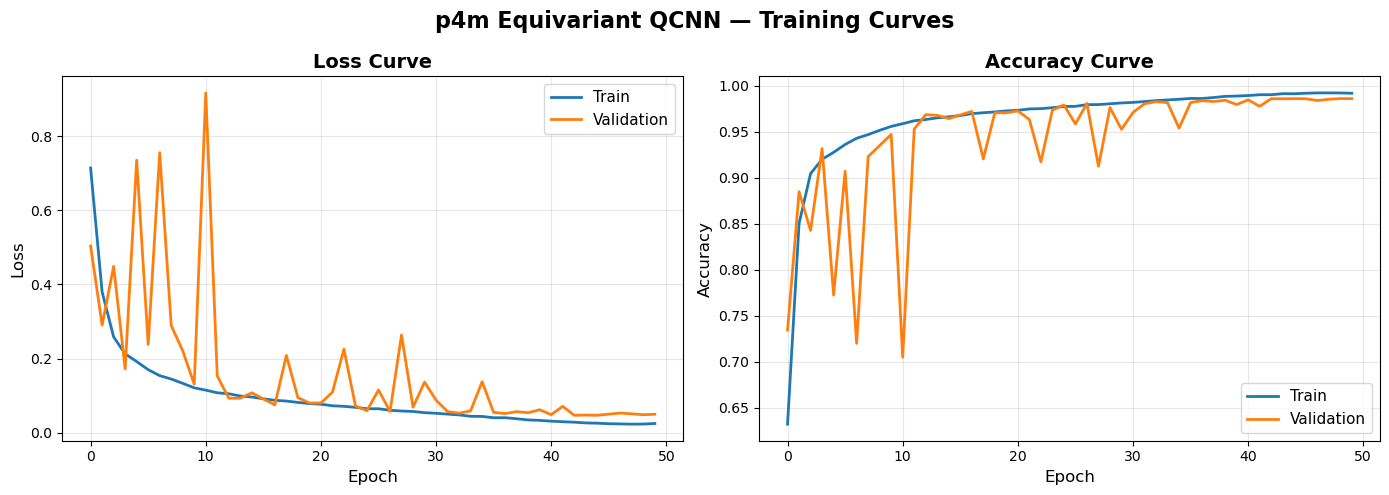

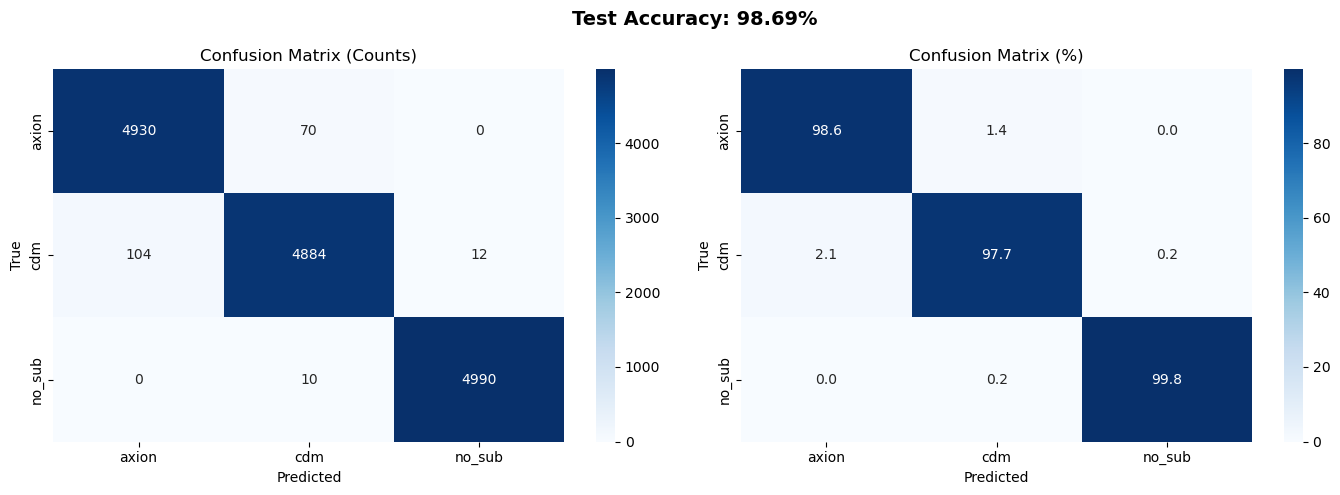


Classification Report:
              precision    recall  f1-score   support

       axion     0.9793    0.9860    0.9827      5000
         cdm     0.9839    0.9768    0.9803      5000
      no_sub     0.9976    0.9980    0.9978      5000

    accuracy                         0.9869     15000
   macro avg     0.9869    0.9869    0.9869     15000
weighted avg     0.9869    0.9869    0.9869     15000



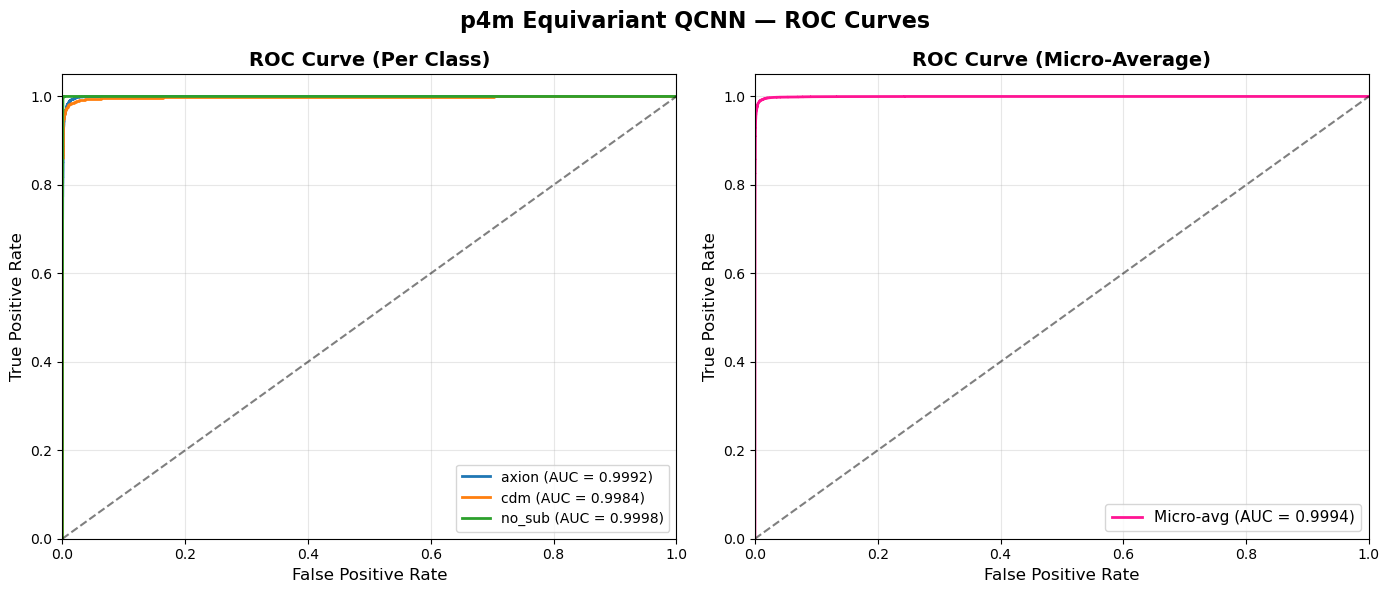


ROC-AUC Summary:
  axion: AUC = 0.9992
  cdm: AUC = 0.9984
  no_sub: AUC = 0.9998
  Micro-avg: AUC = 0.9994


In [54]:
test_acc, test_preds, test_labels, test_probs, test_roc_auc = evaluate_model(
    model, test_loader, device=device
)

test_f1_macro = f1_score(test_labels, test_preds, average='macro')
test_f1_weighted = f1_score(test_labels, test_preds, average='weighted')

print(f"Test Accuracy: {test_acc * 100:.2f}%")
print(f"Test ROC-AUC:  {test_roc_auc:.4f}")
print(f"Test F1 (macro):    {test_f1_macro:.4f}")
print(f"Test F1 (weighted): {test_f1_weighted:.4f}")

plot_training_history(history)
cm = plot_confusion_matrix(test_labels, test_preds, class_names, test_acc)

print("\nClassification Report:")
print(classification_report(test_labels, test_preds,
                            target_names=class_names, digits=4))

roc_auc_dict = plot_roc_curves(test_labels, test_probs, class_names)

print("\nROC-AUC Summary:")
print("=" * 50)
for i, cls in enumerate(class_names):
    print(f"  {cls}: AUC = {roc_auc_dict[i]:.4f}")
print(f"  Micro-avg: AUC = {roc_auc_dict['micro']:.4f}")


In [55]:
torch.save({
    'model_state_dict': model.state_dict(),
    'best_val_acc': max(history['val_acc']),
    'test_acc': test_acc,
    'test_roc_auc': test_roc_auc,
    'history': history,
    'class_names': class_names,
    'n_qubits': n_qubits,
    'img_size': img_size,
    'num_classes': num_classes,
}, CHECKPOINT_PATH)

print(f"Weights saved to {CHECKPOINT_PATH}")
print(f"  Val Accuracy:  {max(history['val_acc'])*100:.2f}%")
print(f"  Test Accuracy: {test_acc*100:.2f}%")
print(f"  Test ROC-AUC:  {test_roc_auc:.4f}")


Weights saved to /home/jovyan/ssh-test-datavol-1/deeplense-quantum/notebooks/equivariant/equiqnn/model_1/checkpoints/best_equiqnn_model_1.pth
  Val Accuracy:  98.60%
  Test Accuracy: 98.69%
  Test ROC-AUC:  0.9991


In [56]:
total_time = time.time() - start_time

print("=" * 60)
print("  p4m Equivariant QCNN — Final Summary")
print("=" * 60)
print(f"\nArchitecture: Hybrid qCNN + p4m Equivariant QCNN")
print(f"  Quantum backend: TorchQuantum")
print(f"\nQuantum Circuit:")
print(f"  Qubits: {n_qubits}")
print(f"  Conv gates: 3 layers of equivariant U2 (RX+IsingZZ+RX+IsingYY)")
print(f"  Pool gates: 3 layers of equivariant pooling (RX+RY+RZ+CRX)")
print(f"  Trainable quantum params: {params['quantum']}")

print(f"\nPerformance:")
print(f"  Best Validation Accuracy: {max(history['val_acc'])*100:.2f}%")
print(f"  Test Accuracy: {test_acc*100:.2f}%")
print(f"  Test ROC-AUC: {test_roc_auc:.4f}")
print(f"  Test F1 (macro): {test_f1_macro:.4f}")
print(f"  Test F1 (weighted): {test_f1_weighted:.4f}")

print(f"\nPer-Class Test Accuracy:")
cm_arr = confusion_matrix(test_labels, test_preds)
for i, cls in enumerate(class_names):
    class_acc = cm_arr[i, i] / cm_arr[i].sum() * 100
    print(f"  {cls}: {class_acc:.2f}%")

print(f"\nTraining Time: {total_time // 60:.0f}m {total_time % 60:.0f}s")
print(f"Total Parameters: {params['total']:,}")
print("=" * 60)


  p4m Equivariant QCNN — Final Summary

Architecture: Hybrid qCNN + p4m Equivariant QCNN
  Quantum backend: TorchQuantum

Quantum Circuit:
  Qubits: 8
  Conv gates: 3 layers of equivariant U2 (RX+IsingZZ+RX+IsingYY)
  Pool gates: 3 layers of equivariant pooling (RX+RY+RZ+CRX)
  Trainable quantum params: 33

Performance:
  Best Validation Accuracy: 98.60%
  Test Accuracy: 98.69%
  Test ROC-AUC: 0.9991
  Test F1 (macro): 0.9869
  Test F1 (weighted): 0.9869

Per-Class Test Accuracy:
  axion: 98.60%
  cdm: 97.68%
  no_sub: 99.80%

Training Time: 214m 52s
Total Parameters: 8,914,060


# QuTiP Visualizations of the Trained Equivariant QCNN

The cells below take the **already-trained** `model` and visualize the quantum
state produced by the `EquivariantQCNN` sub-module using QuTiP. We extract the
statevector right before measurement, convert it to a `qutip.Qobj`, and render:

1. Per-qubit **Bloch spheres** (encoded input vs. output state) for sample images.
2. **Class-averaged Bloch vectors** of the output (active) qubit — the cleanest
   diagnostic of what the QCNN has learned.
3. **Hinton diagram** of the output qubit's reduced density matrix.
4. **Matrix histogram** of |ρ| for the full 8-qubit output state.
5. **Wigner function** of the output qubit's reduced state.
6. A schematic **quantum-circuit diagram** of the equivariant QCNN.

> Requires `qutip` (>=4.7). If not installed: `pip install qutip`.

In [ ]:
import qutip
from qutip import Qobj, Bloch, ptrace, wigner, hinton, matrix_histogram
from qutip.visualization import plot_wigner

print(f"QuTiP version: {qutip.__version__}")

device_q = next(model.parameters()).device
N_QUBITS = model.qcnn.n_qubits


@torch.no_grad()
def get_statevectors(model, x):
    """
    Run the hybrid model up through the QCNN and return:
        psi_in  : statevector right after angle-encoding (encoded input)
        psi_out : statevector right before measurement (QCNN output)
    x: (B, 1, H, W) tensor on the model device.
    Returns two arrays of shape (B, 2**N_QUBITS), complex.
    """
    model.eval()
    feats = model.ecnn(x)
    bridge_out = model.bridge(feats)
    q_in = torch.tanh(bridge_out) * (np.pi / 2)

    qcnn = model.qcnn
    bsz = q_in.shape[0]
    dev = q_in.device

    qdev_in = tq.QuantumDevice(n_wires=N_QUBITS, bsz=bsz, device=dev)
    for i in range(N_QUBITS):
        qdev_in.ry(wires=i, params=q_in[:, i])
    psi_in = qdev_in.get_states_1d().detach().cpu().numpy()

    qdev = tq.QuantumDevice(n_wires=N_QUBITS, bsz=bsz, device=dev)
    pi2 = torch.full((bsz,), np.pi / 2, device=dev, dtype=q_in.dtype)

    c1 = qcnn._expand(qcnn.conv1_params, bsz)
    p1 = qcnn._expand(qcnn.pool1_params, bsz)
    c2 = qcnn._expand(qcnn.conv2_params, bsz)
    p2 = qcnn._expand(qcnn.pool2_params, bsz)
    c3 = qcnn._expand(qcnn.conv3_params, bsz)
    p3 = qcnn._expand(qcnn.pool3_params, bsz)

    for i in range(N_QUBITS):
        qdev.ry(wires=i, params=q_in[:, i])

    for i in range(4):
        qcnn._u2_equiv(qdev, c1, 2 * i, 2 * i + 1, pi2)
    qcnn._u2_equiv(qdev, c1, 1, 2, pi2)
    qcnn._u2_equiv(qdev, c1, 5, 6, pi2)
    qcnn._u2_equiv(qdev, c1, 0, 3, pi2)
    qcnn._u2_equiv(qdev, c1, 4, 7, pi2)
    for i in range(4):
        qcnn._pool_equiv(qdev, p1, 2 * i + 1, 2 * i)
    qcnn._u2_equiv(qdev, c2, 0, 2, pi2)
    qcnn._u2_equiv(qdev, c2, 4, 6, pi2)
    qcnn._pool_equiv(qdev, p2, 2, 0)
    qcnn._pool_equiv(qdev, p2, 6, 4)
    qcnn._u2_equiv(qdev, c3, 0, 4, pi2)
    qcnn._pool_equiv(qdev, p3, 0, 4)
    qdev.h(wires=4)

    psi_out = qdev.get_states_1d().detach().cpu().numpy()
    return psi_in, psi_out


def state_to_qobj(psi):
    """Convert a flat complex numpy statevector (length 2**N) to a QuTiP Qobj ket
    with explicit tensor-product dims = [[2]*N, [1]*N]."""
    n = int(np.log2(psi.size))
    return Qobj(psi.reshape(-1, 1), dims=[[2] * n, [1] * n])


def reduced_dm(psi_np, keep_qubit):
    """Return the 1-qubit reduced density matrix (Qobj) for `keep_qubit`."""
    rho = state_to_qobj(psi_np) * state_to_qobj(psi_np).dag()
    return ptrace(rho, keep_qubit)


def bloch_vector(rho1):
    """Return (x, y, z) Bloch coordinates of a 1-qubit density matrix Qobj."""
    sx = qutip.sigmax()
    sy = qutip.sigmay()
    sz = qutip.sigmaz()
    return (np.real((rho1 * sx).tr()),
            np.real((rho1 * sy).tr()),
            np.real((rho1 * sz).tr()))


x_batch, y_batch = next(iter(test_loader))
x_batch = x_batch.to(device_q)
y_batch_np = y_batch.numpy()

psi_in_batch, psi_out_batch = get_statevectors(model, x_batch)
print(f"Extracted statevectors: in={psi_in_batch.shape}, out={psi_out_batch.shape}")
print(f"Batch labels: {y_batch_np[:8]}  (classes: {class_names})")


QuTiP version: 5.2.3
Extracted statevectors: in=(64, 256), out=(64, 256)
Batch labels: [0 0 0 0 0 0 0 0]  (classes: ['axion', 'cdm', 'no_sub'])


## 1. Per-qubit Bloch spheres — encoded input vs. QCNN output

For a single sample image we plot the reduced single-qubit state on the Bloch
sphere for all 8 qubits, **before** and **after** the equivariant QCNN. After
the QCNN the *active output* qubit is qubit 4 (the rest have been "pooled" and
are entangled / partially mixed).

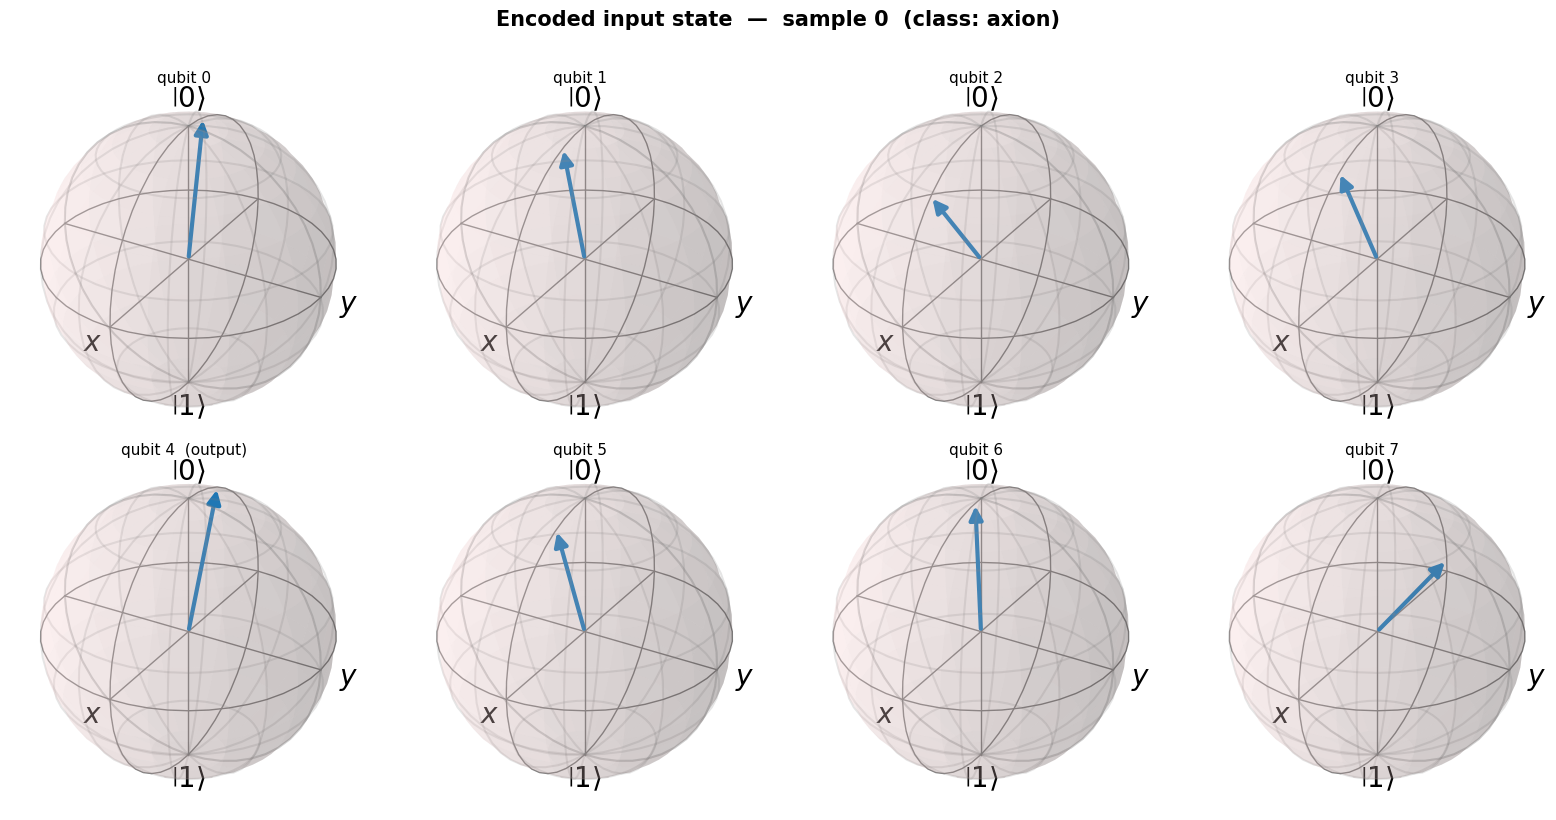

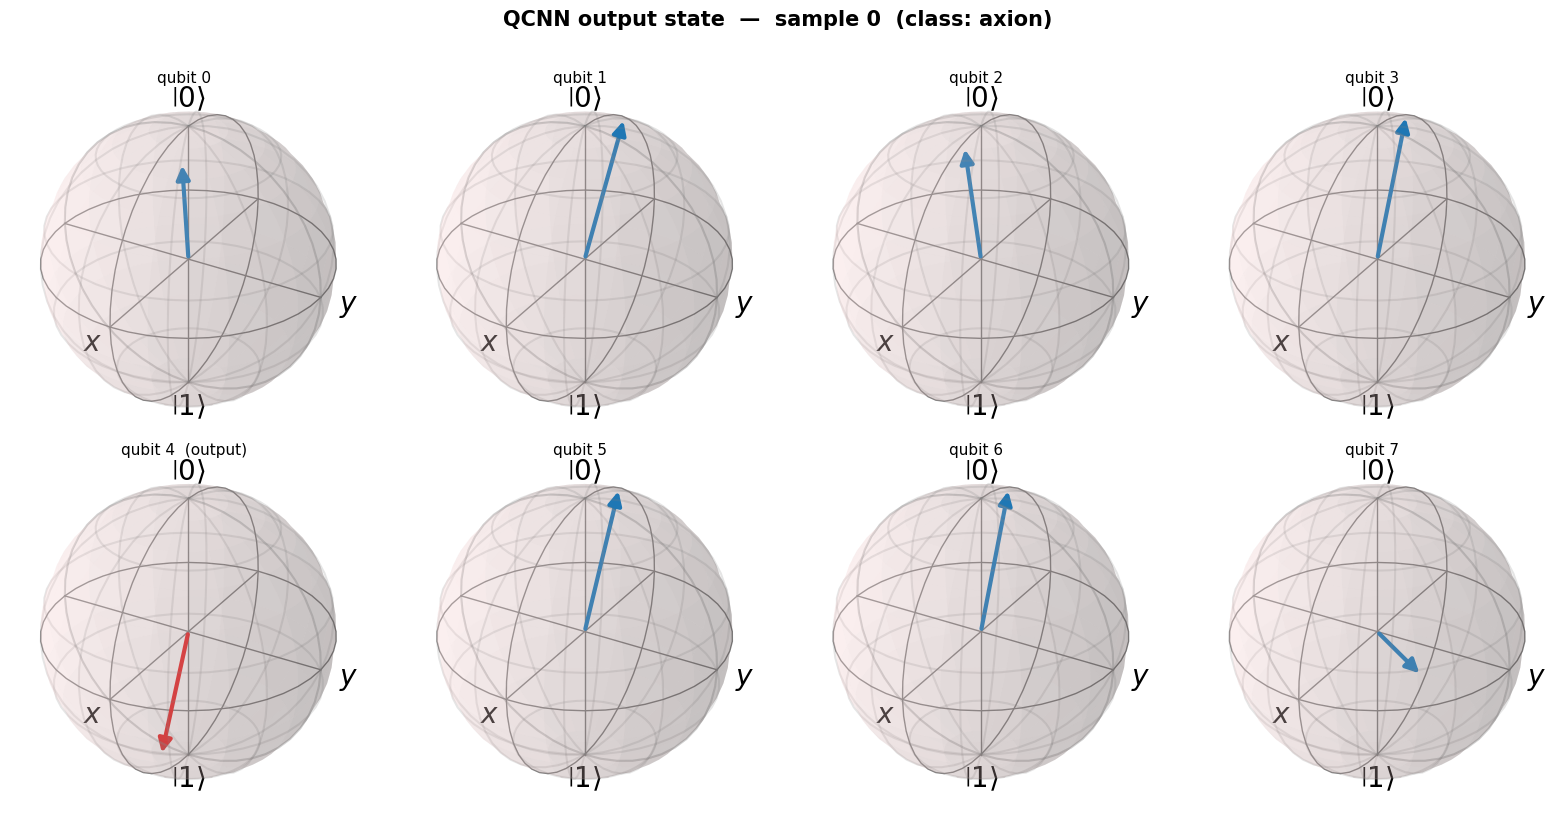

In [ ]:
def plot_bloch_grid(psi_np, title, save_path, highlight_qubit=None):
    fig = plt.figure(figsize=(16, 8))
    for q in range(N_QUBITS):
        ax = fig.add_subplot(2, 4, q + 1, projection='3d')
        b = Bloch(axes=ax)
        b.point_size = [40]
        b.vector_width = 3
        if highlight_qubit is not None and q == highlight_qubit:
            b.vector_color = ['#d62728']
            b.point_color = ['#d62728']
        else:
            b.vector_color = ['#1f77b4']
            b.point_color = ['#1f77b4']
        rho1 = reduced_dm(psi_np, q)
        b.add_states(rho1)
        b.render()
        ax.set_title(f"qubit {q}" + ("  (output)" if q == 4 else ""),
                     fontsize=11)
    plt.suptitle(title, fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


sample_idx = 0
true_cls = class_names[y_batch_np[sample_idx]]

plot_bloch_grid(
    psi_in_batch[sample_idx],
    title=f"Encoded input state  —  sample 0  (class: {true_cls})",
    save_path=RESULTS_DIR / 'bloch_encoded_input.png'
)
plot_bloch_grid(
    psi_out_batch[sample_idx],
    title=f"QCNN output state  —  sample 0  (class: {true_cls})",
    save_path=RESULTS_DIR / 'bloch_qcnn_output.png',
    highlight_qubit=4
)


## 2. Class-separated Bloch sphere of the output qubit

This is the most informative QuTiP visualization for a classifier QCNN: we
collect the **Bloch vectors of the output qubit (qubit 4)** across a chunk of
the test set, color-code them by true class, and plot them on a single Bloch
sphere. Good separation of the three colored clouds visually explains the high
test accuracy.

  axion   : 50 samples
  cdm     : 50 samples
  no_sub  : 50 samples


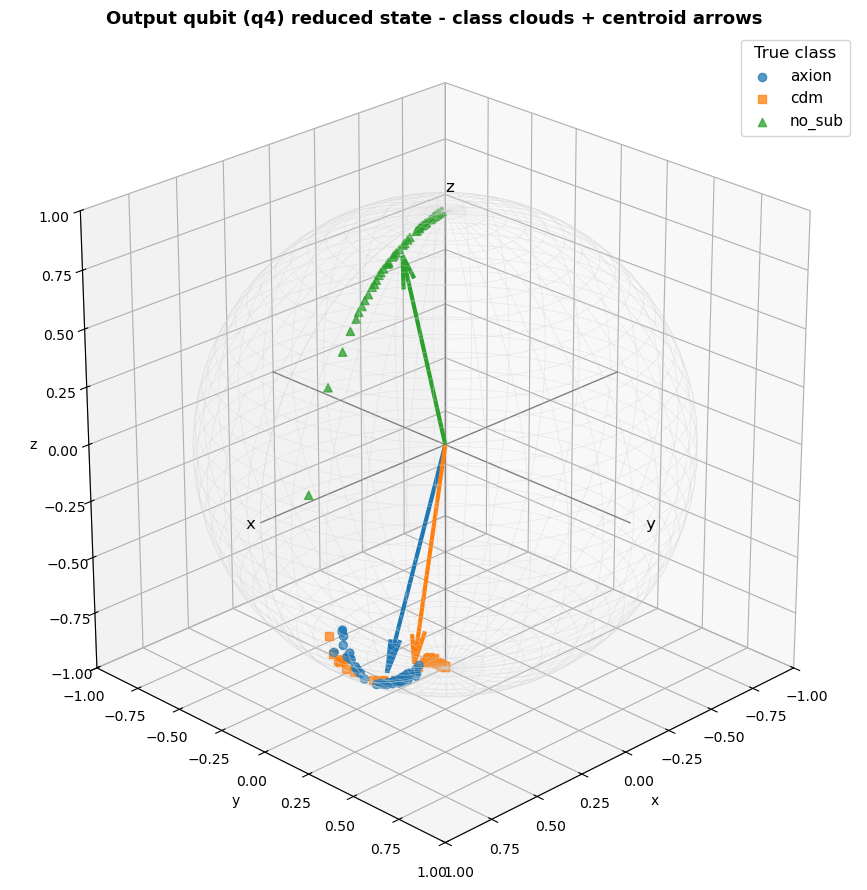


Class-centroid Bloch coordinates:
  axion   :  x=+0.403   y=+0.075   z=-0.844   |r|=0.938
  cdm     :  x=+0.174   y=-0.004   z=-0.919   |r|=0.936
  no_sub  :  x=+0.281   y=+0.049   z=+0.908   |r|=0.952


In [62]:
MAX_SAMPLES_PER_CLASS = 50
OUTPUT_QUBIT = 4

bloch_vectors_per_class = {c: [] for c in range(len(class_names))}

model.eval()
n_seen = {c: 0 for c in range(len(class_names))}

for x_b, y_b in test_loader:
    if all(n_seen[c] >= MAX_SAMPLES_PER_CLASS for c in n_seen):
        break

    x_b = x_b.to(device_q)

    with torch.no_grad():
        _, psi_out_b = get_statevectors(model, x_b)

    y_np = y_b.cpu().numpy()

    for i in range(len(y_np)):
        c = int(y_np[i])

        if n_seen[c] >= MAX_SAMPLES_PER_CLASS:
            continue

        rho1 = reduced_dm(psi_out_b[i], OUTPUT_QUBIT)
        rvec = np.asarray(bloch_vector(rho1), dtype=float).reshape(3)

        bloch_vectors_per_class[c].append(rvec)
        n_seen[c] += 1

for c, v in bloch_vectors_per_class.items():
    bloch_vectors_per_class[c] = np.array(v, dtype=float)
    print(f"  {class_names[c]:<8s}: {bloch_vectors_per_class[c].shape[0]} samples")


class_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
class_markers = ['o', 's', '^', 'd', 'p']

plt.close('all')

fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111, projection='3d')

# Draw Bloch sphere
u = np.linspace(0, 2 * np.pi, 80)
v = np.linspace(0, np.pi, 40)

xs = np.outer(np.cos(u), np.sin(v))
ys = np.outer(np.sin(u), np.sin(v))
zs = np.outer(np.ones_like(u), np.cos(v))

ax.plot_wireframe(xs, ys, zs, color='lightgray', linewidth=0.5, alpha=0.45)

# Coordinate axes
ax.plot([-1, 1], [0, 0], [0, 0], color='gray', linewidth=1)
ax.plot([0, 0], [-1, 1], [0, 0], color='gray', linewidth=1)
ax.plot([0, 0], [0, 0], [-1, 1], color='gray', linewidth=1)

ax.text(1.08, 0, 0, 'x', fontsize=12)
ax.text(0, 1.08, 0, 'y', fontsize=12)
ax.text(0, 0, 1.08, 'z', fontsize=12)

# Plot class clouds and centroid arrows
for c in range(len(class_names)):
    pts = bloch_vectors_per_class[c]

    if pts.size == 0:
        continue

    color = class_colors[c % len(class_colors)]
    marker = class_markers[c % len(class_markers)]

    ax.scatter(
        pts[:, 0],
        pts[:, 1],
        pts[:, 2],
        s=35,
        marker=marker,
        color=color,
        alpha=0.75,
        label=class_names[c],
    )

    cx, cy, cz = pts.mean(axis=0)

    ax.quiver(
        0, 0, 0,
        cx, cy, cz,
        color=color,
        linewidth=3,
        arrow_length_ratio=0.15,
    )

ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-1, 1])

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')

ax.set_box_aspect([1, 1, 1])
ax.view_init(elev=25, azim=45)

ax.legend(
    loc='upper right',
    fontsize=11,
    title='True class',
    title_fontsize=12,
)

plt.title(
    f"Output qubit (q{OUTPUT_QUBIT}) reduced state - class clouds + centroid arrows",
    fontsize=13,
    fontweight='bold',
)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / 'bloch_classes_output_qubit.png',
    dpi=150,
    bbox_inches='tight',
)

plt.show()


print("\nClass-centroid Bloch coordinates:")

for c in range(len(class_names)):
    pts = bloch_vectors_per_class[c]

    if pts.size == 0:
        print(f"  {class_names[c]:<8s}:  no samples")
        continue

    cx, cy, cz = pts.mean(axis=0)
    r = np.sqrt(cx**2 + cy**2 + cz**2)

    print(
        f"  {class_names[c]:<8s}:  "
        f"x={cx:+.3f}   y={cy:+.3f}   z={cz:+.3f}   |r|={r:.3f}"
    )

## 3. Hinton diagram + matrix histogram of the output density matrix

`hinton` shows each entry of the density matrix as a square whose **area** is
proportional to |ρᵢⱼ| and whose **color** encodes sign (white = +, black = −).
`matrix_histogram` is the 3D-bar version. We plot:

* The 2×2 reduced ρ of the **output qubit** (per class — clearly different).
* The full 256×256 |ρ| of the 8-qubit output state (single sample, log-magnitude).

/tmp/ipykernel_232/1572284499.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


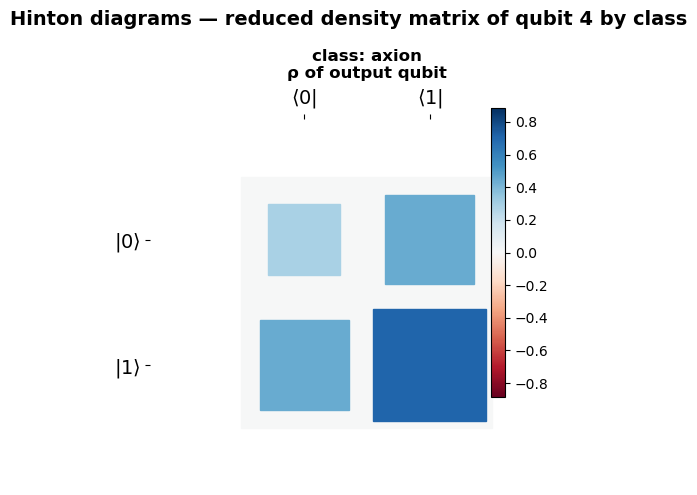

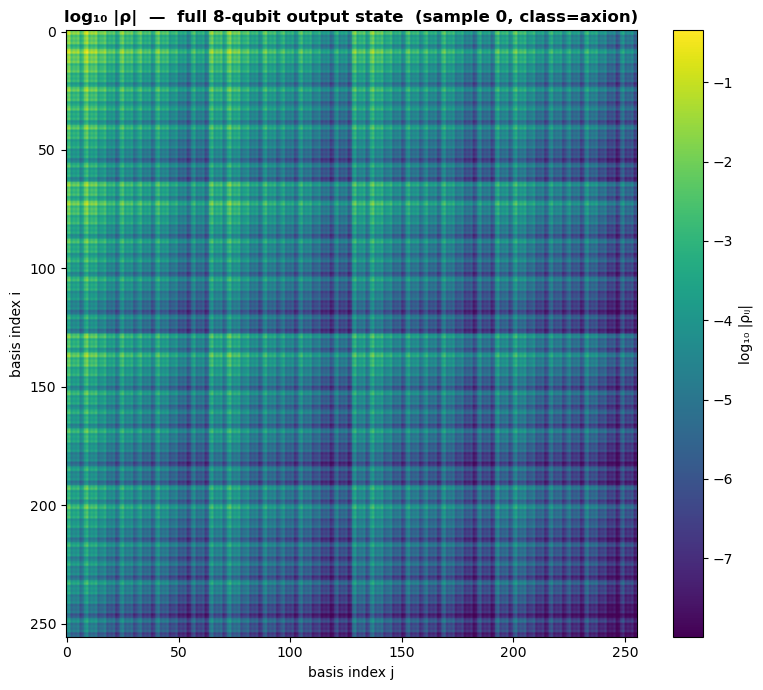

State purity Tr(ρ²) of full output state: 0.9894
Purity of reduced output qubit (q4):      0.9833


In [63]:
first_idx_per_class = {}
for c in range(len(class_names)):
    matches = np.where(y_batch_np == c)[0]
    if matches.size > 0:
        first_idx_per_class[c] = int(matches[0])

fig, axes = plt.subplots(1, len(first_idx_per_class),
                         figsize=(5 * len(first_idx_per_class), 5),
                         subplot_kw={'aspect': 'equal'})
if len(first_idx_per_class) == 1:
    axes = [axes]

for ax, (c, idx) in zip(axes, first_idx_per_class.items()):
    rho1 = reduced_dm(psi_out_batch[idx], OUTPUT_QUBIT)
    hinton(rho1, ax=ax)
    ax.set_title(f"class: {class_names[c]}\nρ of output qubit",
                 fontsize=12, fontweight='bold')

plt.suptitle("Hinton diagrams — reduced density matrix of qubit 4 by class",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'hinton_output_qubit_per_class.png', dpi=150, bbox_inches='tight')
plt.show()


sample_idx = first_idx_per_class[0]
psi_full = state_to_qobj(psi_out_batch[sample_idx])
rho_full = psi_full * psi_full.dag()
rho_abs = np.abs(rho_full.full())

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(np.log10(rho_abs + 1e-8), cmap='viridis', aspect='auto')
ax.set_title(f"log₁₀ |ρ|  —  full 8-qubit output state  (sample 0, class={class_names[y_batch_np[sample_idx]]})",
             fontsize=12, fontweight='bold')
ax.set_xlabel("basis index j")
ax.set_ylabel("basis index i")
plt.colorbar(im, ax=ax, label='log₁₀ |ρᵢⱼ|')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'full_density_matrix_log.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"State purity Tr(ρ²) of full output state: {(rho_full * rho_full).tr().real:.4f}")
print(f"Purity of reduced output qubit (q4):      "
      f"{(reduced_dm(psi_out_batch[sample_idx], OUTPUT_QUBIT) ** 2).tr().real:.4f}")


## 4. Wigner functions of the output qubit (per class)

For a qubit, the (spin) Wigner function lives on the Bloch sphere; the
`plot_wigner` helper draws it on the (x, y) plane. Negative regions indicate
genuinely non-classical structure.